In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

### 데이터 불러오기(금시세 2000~2005년도)

In [2]:
# Yahoo Finance에서 수집한 CSV
file_path = "../Data-collection/dailyStock"
target = "GC=F"
file_path = f"{file_path}/{target}.csv"
df = pd.read_csv(file_path, encoding="utf-8")

# 날짜 변환
df['Date'] = pd.to_datetime(df['Date'])

# Prophet 형식으로 변경
df = df.rename(columns={'Date': 'ds','Close': 'y'})

# 필요한 컬럼만 사용
df = df[['ds', 'y']]

# 기간 설정
df = df.loc[(df['ds'] >= '2000-01-01') & (df['ds'] <= '2005-12-31')]

### 테스트데이터와 검증데이터로 분리

In [3]:
train_indices = df['ds'].dt.year < 2005

df_train = df.loc[train_indices].dropna()               #2000~2004년 테스트데이터로 사용
df_test = df.loc[~train_indices].reset_index(drop=True) #2005년 검증데이터로 사용

### 학습실행

In [4]:
model_prophet = Prophet(seasonality_mode='additive')   #가산(additive) 방식으로 모델링(추세+계절성+기타변동)
model_prophet.add_seasonality(name='monthly', period=30.5, fourier_order=5)  #한달 주기로 계정성 패턴 측정
model_prophet.fit(df_train)

20:35:08 - cmdstanpy - INFO - Chain [1] start processing
20:35:09 - cmdstanpy - INFO - Chain [1] done processing


### 예측결과 도식화

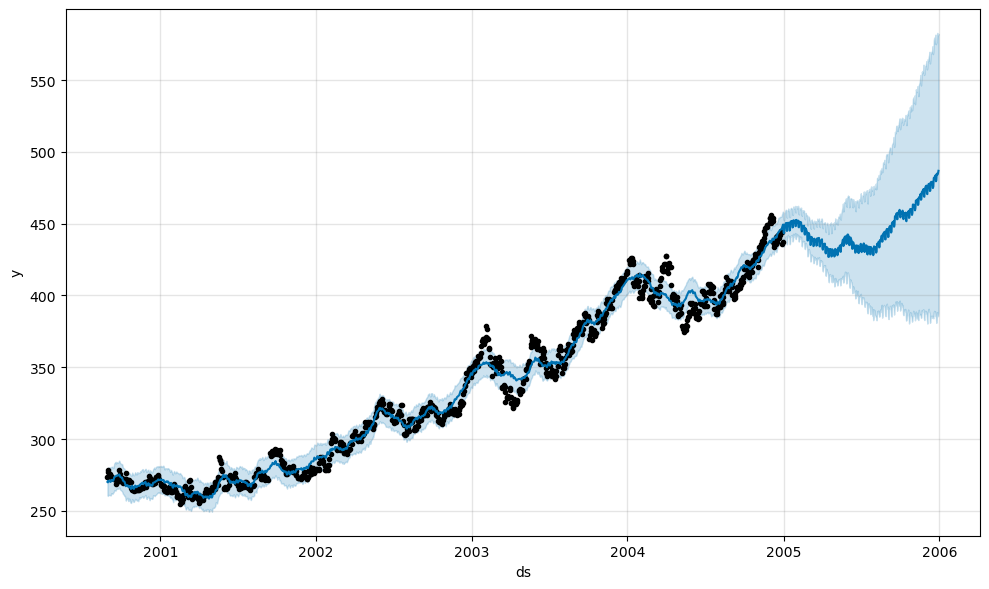

In [5]:
df_future = model_prophet.make_future_dataframe(periods=365)
df_pred = model_prophet.predict(df_future)
model_prophet.plot(df_pred)

plt.tight_layout()
plt.show()

### 시계열 분해 검사

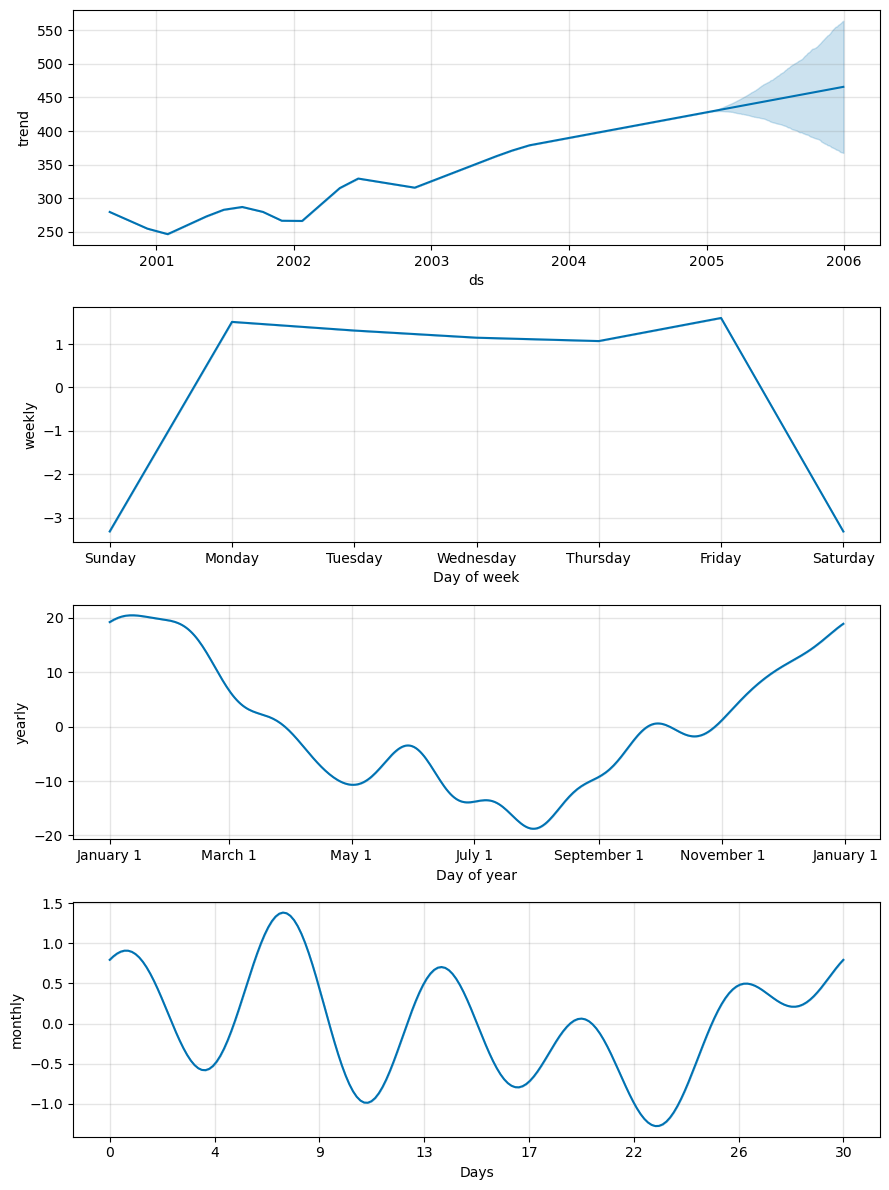

In [6]:
model_prophet.plot_components(df_pred)
plt.tight_layout()
plt.show()

### 예측값과 실제값 비교

In [9]:
selected_columns = ['ds', 'yhat_lower', 'yhat_upper', 'yhat']

df_pred = df_pred.loc[:, selected_columns].reset_index(drop=True)
df_test = df_test.merge(df_pred, on=['ds'], how='left')
df_test.ds = pd.to_datetime(df_test.ds)
df_test.set_index('ds', inplace=True)

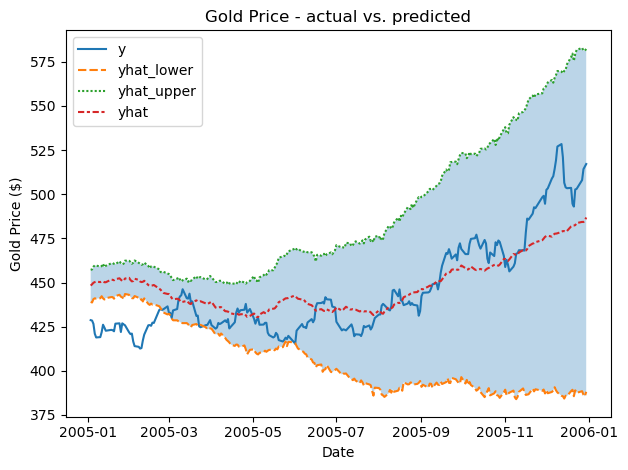

In [13]:
fig, ax = plt.subplots(1, 1)

ax = sns.lineplot(data=df_test[['y', 'yhat_lower', 
                                'yhat_upper', 'yhat']])
ax.fill_between(df_test.index,
                df_test.yhat_lower,
                df_test.yhat_upper,
                alpha=0.3)
ax.set(title='Gold Price - actual vs. predicted',
       xlabel='Date',
       ylabel='Gold Price ($)')

plt.tight_layout()
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1327
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      1328 non-null   datetime64[ns]
 1   y       1328 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 31.1 KB
